In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

We perform a classification task to determine whether an apartment in Germany should be purchased, based on the predicted total rent. Since `totalRent` is directly related to the decision, we remove this variable from the feature set to avoid data leakage. Instead, we construct a binary target variable `rent_house`, defined using the median value of `totalRent` (approximately 622) as the threshold: apartments with `totalRent` above this value are labeled as 1 (buy), and those below are labeled as 0 (not buy).

In [3]:
threshold = 622

train_df["rent_house"] = (train_df["totalRent"] >= threshold).astype(int)
val_df["rent_house"] = (val_df["totalRent"] >= threshold).astype(int)
test_df["rent_house"] = (test_df["totalRent"] >= threshold).astype(int)

In [4]:
target = ['rent_house']

X_train = train_df.drop(columns=['rent_house', 'totalRent'])
y_train = train_df['rent_house']

X_val = val_df.drop(columns=['rent_house', 'totalRent'])
y_val = val_df['rent_house']

X_test = test_df.drop(columns=['rent_house', 'totalRent'])
y_test = test_df['rent_house']

# Decision Tree

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

params = [
    (3, 10),
    (5, 20),
    (7, 20),
    (10, 20),
    (5, 50),
    (7, 50)
]

for depth, leaf in params:
    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=leaf,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    print(f"max_depth={depth}, min_leaf={leaf} → Acc={acc:.4f}, F1={f1:.4f}")

max_depth=3, min_leaf=10 → Acc=0.8999, F1=0.9120
max_depth=5, min_leaf=20 → Acc=0.9052, F1=0.9158
max_depth=7, min_leaf=20 → Acc=0.9105, F1=0.9215
max_depth=10, min_leaf=20 → Acc=0.9130, F1=0.9241
max_depth=5, min_leaf=50 → Acc=0.9052, F1=0.9158
max_depth=7, min_leaf=50 → Acc=0.9103, F1=0.9214


In [6]:
best_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)

best_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}, Test F1 Score: {test_f1:.4f}")

Test Accuracy: 0.9130, Test F1 Score: 0.9240


In [8]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

baseRent                                      0.888257
serviceCharge                                 0.051947
livingSpace                                   0.015605
regio2_freq                                   0.009517
regio1_nordrhein_westfalen                    0.004460
regio1_niedersachsen                          0.003922
condition_unknown                             0.003741
heatingType_self_contained_central_heating    0.003589
heatingType_district_heating                  0.002359
yearConstructed                               0.002084
dtype: float64


### Maybe it is overfitting

In [9]:
target = ['buy_house']

X_train = X_train.drop(columns=['baseRent'])
X_val = X_val.drop(columns=['baseRent'])
X_test = X_test.drop(columns=['baseRent'])

## Why `baseRent` Was Removed

`baseRent` was removed to prevent **data leakage**.

The target variable (`buy_house`) is derived from `totalRent`, while:

```
totalRent ≈ baseRent + serviceCharge
```

This means `baseRent` contains direct information about the target. When included, the model relies heavily on it instead of learning meaningful patterns, leading to artificially high performance.

After removing `baseRent`, the model becomes:

* More realistic
* More interpretable
* Based on actual features (e.g., living space, price trend)

Although performance decreases, the model is **more reliable and valid**.


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

params = [
    (3, 10),
    (5, 20),
    (7, 20),
    (10, 20),
    (5, 50),
    (7, 50)
]

for depth, leaf in params:
    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=leaf,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    print(f"max_depth={depth}, min_leaf={leaf} → Acc={acc:.4f}, F1={f1:.4f}")

max_depth=3, min_leaf=10 → Acc=0.7918, F1=0.8101
max_depth=5, min_leaf=20 → Acc=0.8108, F1=0.8346
max_depth=7, min_leaf=20 → Acc=0.8244, F1=0.8443
max_depth=10, min_leaf=20 → Acc=0.8447, F1=0.8681
max_depth=5, min_leaf=50 → Acc=0.8106, F1=0.8344
max_depth=7, min_leaf=50 → Acc=0.8248, F1=0.8447


In [11]:
best_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)

best_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}, Test F1 Score: {test_f1:.4f}")

Test Accuracy: 0.8450, Test F1 Score: 0.8686


# Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=10000, random_state=0))
])
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [14]:
y_pred = model.predict(X_val)
acc = accuracy_score(y_val, y_pred) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

Logistic Regression model accuracy: 83.93%


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80     17318
           1       0.87      0.86      0.86     25698

    accuracy                           0.84     43016
   macro avg       0.83      0.83      0.83     43016
weighted avg       0.84      0.84      0.84     43016

[[13959  3359]
 [ 3554 22144]]


In [16]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred) * 100
print(f"Logistic Regression model accuracy on test set: {acc:.2f}%")

Logistic Regression model accuracy on test set: 83.98%


## Gaussian Naive Bayes

In [17]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

model = GaussianNB(priors=[0.4, 0.6])
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.91      0.71     17318
           1       0.90      0.56      0.69     25698

    accuracy                           0.70     43016
   macro avg       0.74      0.73      0.70     43016
weighted avg       0.77      0.70      0.70     43016

[[15696  1622]
 [11295 14403]]


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, log_loss

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Log Loss:", log_loss(y_test, y_prob))

Accuracy: 0.6967453970615585
Precision: 0.8985857365745634
Recall: 0.5554207497277959
F1: 0.6865074787557196
Confusion Matrix:
 [[19610  2015]
 [14291 17854]]
ROC-AUC: 0.8327188633153423
Log Loss: 4.3156638972258765


## Multi-Layer Perception

In [19]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [20]:
class MLPBinary(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [21]:
input_dim = X_train.shape[1]
print(f"Input dimension: {input_dim}")
model = MLPBinary(input_dim)

criterion = nn.BCELoss()  # Binary cross-entropy
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

Input dimension: 63


In [22]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 64

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [23]:
train_losses = []
val_losses = []

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)  
    
    # Validation
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)      
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/20, Train Loss: 0.3616, Val Loss: 0.3410
Epoch 2/20, Train Loss: 0.3444, Val Loss: 0.3291
Epoch 3/20, Train Loss: 0.3389, Val Loss: 0.3309
Epoch 4/20, Train Loss: 0.3355, Val Loss: 0.3224
Epoch 5/20, Train Loss: 0.3324, Val Loss: 0.3228
Epoch 6/20, Train Loss: 0.3316, Val Loss: 0.3190
Epoch 7/20, Train Loss: 0.3288, Val Loss: 0.3234
Epoch 8/20, Train Loss: 0.3273, Val Loss: 0.3193
Epoch 9/20, Train Loss: 0.3263, Val Loss: 0.3234
Epoch 10/20, Train Loss: 0.3261, Val Loss: 0.3158
Epoch 11/20, Train Loss: 0.3248, Val Loss: 0.3194
Epoch 12/20, Train Loss: 0.3237, Val Loss: 0.3153
Epoch 13/20, Train Loss: 0.3228, Val Loss: 0.3164
Epoch 14/20, Train Loss: 0.3225, Val Loss: 0.3115
Epoch 15/20, Train Loss: 0.3216, Val Loss: 0.3121
Epoch 16/20, Train Loss: 0.3214, Val Loss: 0.3126
Epoch 17/20, Train Loss: 0.3197, Val Loss: 0.3108
Epoch 18/20, Train Loss: 0.3194, Val Loss: 0.3096
Epoch 19/20, Train Loss: 0.3203, Val Loss: 0.3104
Epoch 20/20, Train Loss: 0.3185, Val Loss: 0.3096


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, log_loss

model.eval()
with torch.no_grad():
    y_prob = model(X_test).numpy()
    y_pred = (y_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Log Loss:", log_loss(y_test, y_prob))

Accuracy: 0.8642551608703738
Precision: 0.9014412201900084
Recall: 0.8678177010421527
F1: 0.884309964971232
Confusion Matrix:
 [[18575  3050]
 [ 4249 27896]]
ROC-AUC: 0.938128860824821
Log Loss: 0.3086499650124966


## Visualization

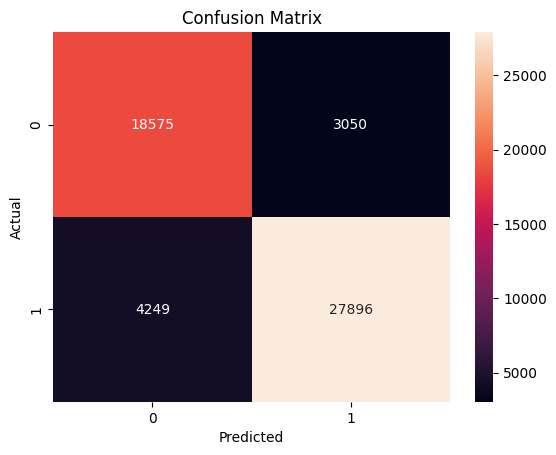

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

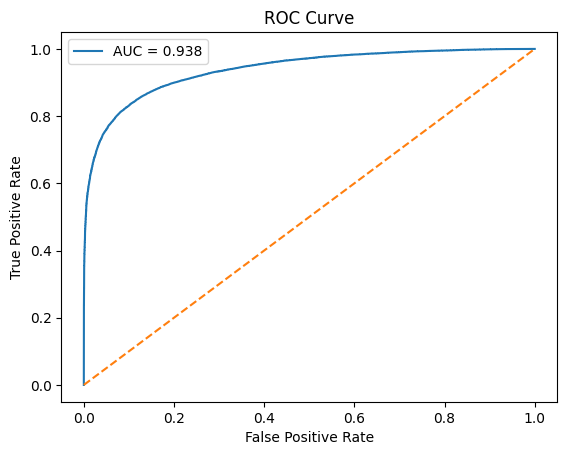

In [26]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

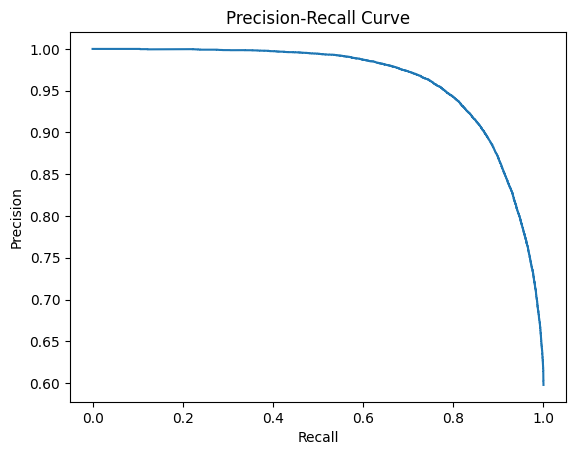

In [27]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

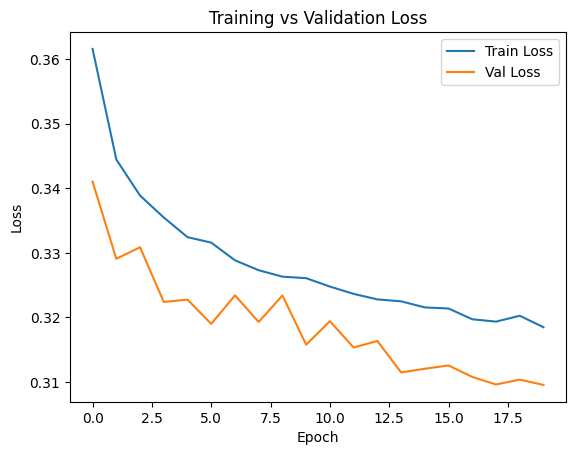

In [28]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

The prediction probability distribution shows two distinct clusters near 0 and 1, indicating that the model can effectively separate the two classes. However, there remains a region of intermediate probabilities where the model is less confident. This explains why the log loss is not extremely low, despite strong classification performance in terms of F1-score and ROC-AUC.


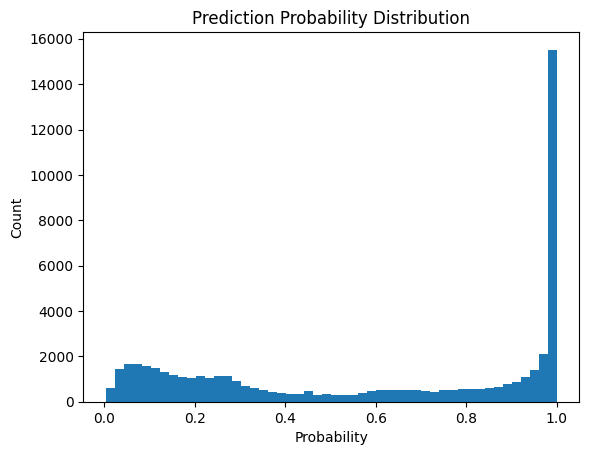

In [29]:
plt.figure()
plt.hist(y_prob, bins=50)
plt.title("Prediction Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()